# Rep. 2. Checkpoint 2. Mov. Geométrico Browniano


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import datetime as dt

In [60]:
stocks = ["JPM","META","TSM","LLY"]
weights = np.array([0.65,0.10,0.15,0.10])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=365*3)

In [61]:
prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\nMatriz de covarianza:")
print(cov_matrix)

C:\Users\j_ale\AppData\Local\Temp\ipykernel_17276\4047356346.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]


Media diaria retornos:
Ticker
JPM     0.001257
LLY     0.001805
META    0.002016
TSM     0.002246
dtype: float64

Matriz de covarianza:
Ticker       JPM       LLY      META       TSM
Ticker                                        
JPM     0.000219  0.000045  0.000094  0.000093
LLY     0.000045  0.000476  0.000090  0.000068
META    0.000094  0.000090  0.000518  0.000229
TSM     0.000093  0.000068  0.000229  0.000564


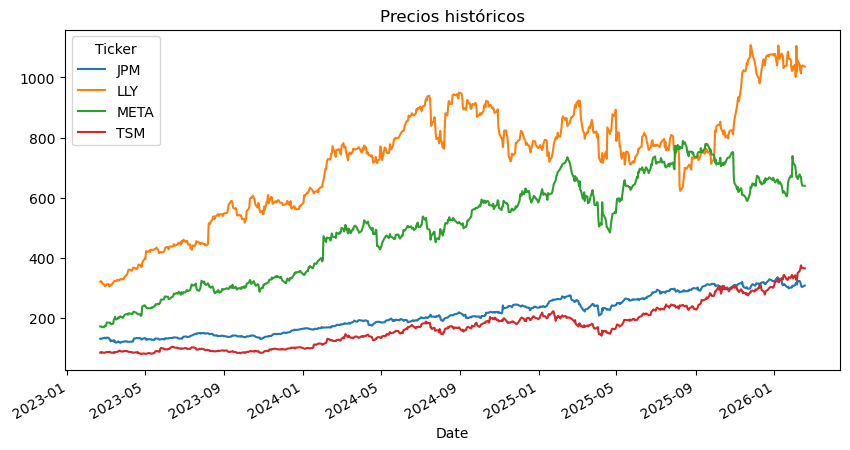

In [62]:
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

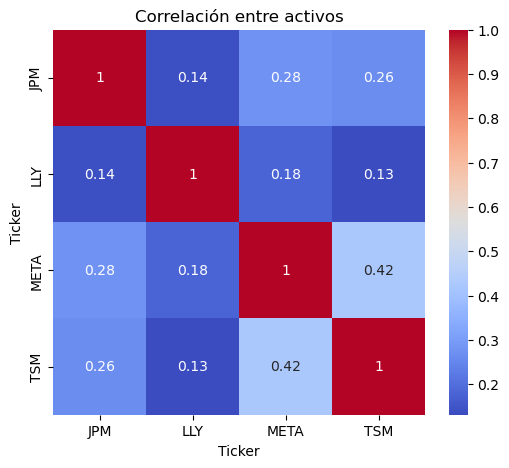

In [63]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

Responder brevemente en comentarios dentro del código:

¿Qué activos están más correlacionados? Meta y TSM

¿El portafolio parece estable o muy variable? Estable

¿Cuál activo parece dominar el comportamiento del portafolio? Meta



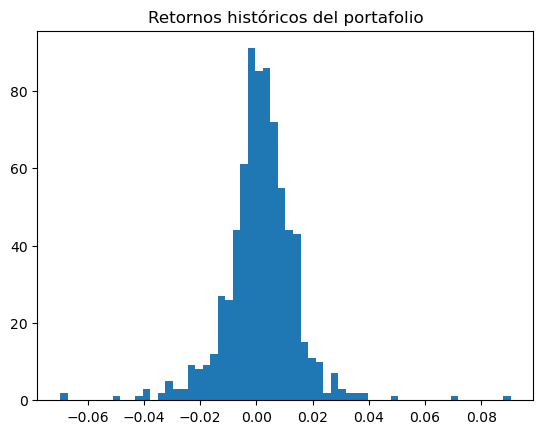

Volatilidad histórica diaria: 0.012725681700829477


In [64]:
portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()

print("Volatilidad histórica diaria:", portfolio_hist.std())

## Simulación

In [65]:
num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))

In [66]:
for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)

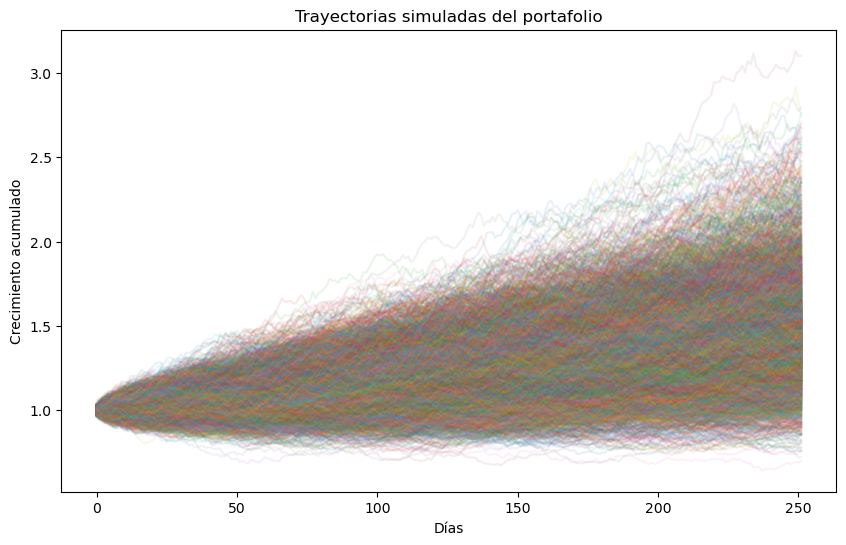

In [67]:
plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

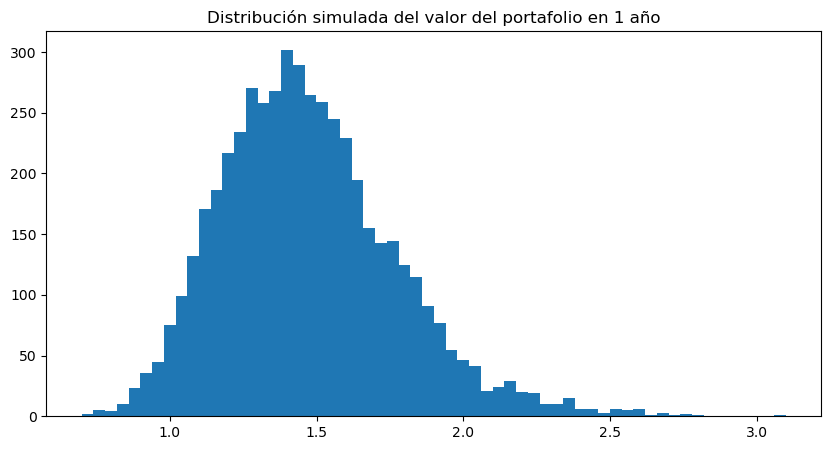

Valor esperado final: 1.4723923431870276
Probabilidad de pérdida: 0.03
Maximo de las simulaciones: 3.100664494236069
Minimo de las simulaciones: 0.6986809775902934


In [68]:
final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))
print("Maximo de las simulaciones:",np.max(final_values))
print("Minimo de las simulaciones:",np.min(final_values))

Responder en comentarios en Markdown:

¿Las trayectorias simuladas son similares entre sí o muy distintas? Algunas son similares y algunas otras son muy distintas.

¿La dispersión aumenta con el tiempo? Si, como si fuera una normal.

¿Qué observas en la distribución final del portafolio? Parece ser una normal, pero con un sesgo positivo y aparte es un poco mas ancho.

# Compara tus resultado

### Portafolio 1
- stocks = ["JPM","META","TSM","LLY"]
- weights = np.array([0.20,0.40,0.15,0.25])
#### Resultados
- Valor esperado final: 1.588733726922375
- Probabilidad de pérdida: 0.0262

### Portafolio 2
- stocks = ["JPM","META","TSM","LLY"]
- weights = np.array([0.65,0.10,0.15,0.10])
#### Resultados
- Valor esperado final: 1.466620562891473
- Probabilidad de pérdida: 0.0304

### ¿Qué observas al modificar el portafolio?
Al modificar los pesos del portafolio y poner la mayoría de peso a un solo activo, veo una disminución de retorno esperado y un aumento en riesgo; el aumento de riesgo probablemente se deba a que hay una menor diversificación.